In [1]:
import math
# Define Box Parameters
# Let's divide the pitch into boxes
# Each box can be occupied by a max of 5 players

# define pitch 
Pitch_Length = 105 # meters
Pitch_Width = 68 # meters

# define our player size: player is a circle because we expect a player to occupy the same space in all orientations
player_radius = 0.3 #m 
player_area = math.pi * 0.3**2
box_len = 5 #m
box_wid = 4 #m
box_area = box_len * box_wid
# Number of boxes required to cover the pitch
count_len = Pitch_Length // box_len
count_wid = Pitch_Width // box_wid
num_boxes = count_len * count_wid

# How can players be stack in a box ? 
# In a realistic setting, when an attacker is being blocked by opposing players we assume that they do not intend
# to restrict each others movement. We can define this in terms of the distance a player needs to reach in order to complete a succesful tackle

leg_reach = 0.8          #m  # average length to which a player streaches their leg for an attack
ball_control_radius = 0.6 #m # how far ball may be from attacker

tackle_radius = leg_reach +  ball_control_radius + player_radius # length below which a tackle is possible

# Number of players in a box would typically mean, how many players and an attacker that can fit within a box
tackle_area = math.pi * tackle_radius**2
print(num_boxes)   
print(f"Tackle radius: {tackle_radius:.2f}m")

357
Tackle radius: 1.70m


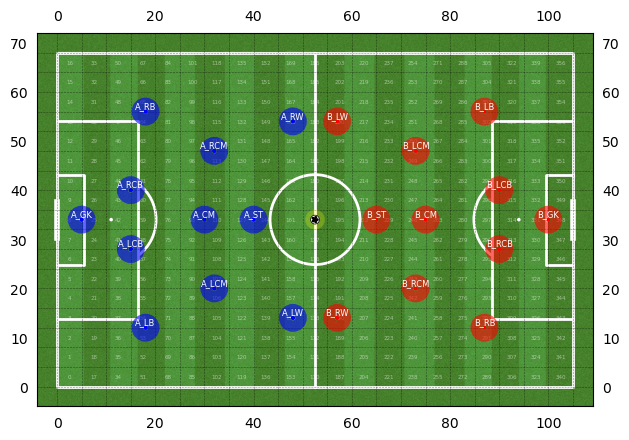

In [34]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
import numpy as np
pitch = Pitch()
pitch = Pitch(
    pitch_type='custom',
    pitch_length=Pitch_Length,
    pitch_width=Pitch_Width,
    pitch_color='grass',
    line_color='white',
    stripe=True,
    axis=True,
    label=True
)

# -------------------------
# Ball model
# -------------------------
ball_radius = 0.11  # roughly football radius in metres

ball = {
    "x": Pitch_Length / 2,
    "y": Pitch_Width / 2,
    "owner": None
}
fig, ax = pitch.draw()

for x in range(0, Pitch_Length + 1, box_len):
    ax.axvline(x, color='black', linestyle='--', linewidth=0.4, alpha=0.5)

for y in range(0, Pitch_Width + 1, box_wid):
    ax.axhline(y, color='black', linestyle='--', linewidth=0.4, alpha=0.5)

# Optional: label cells
cell_id = 0
for i in range(count_len):
    for j in range(count_wid):
        cx = i * box_len + box_len / 2
        cy = j * box_wid + box_wid / 2

        ax.text(
            cx, cy, str(cell_id),
            ha='center',
            va='center',
            fontsize=4,
            color='white',
            alpha=0.5
        )

        cell_id += 1

# Basic 4-3-3 formation, attacking left to right
HALF = Pitch_Length / 2
# Team A: left half, attacking left to right
team_a_433 = [
    ("A_GK", 5, 34),

    ("A_LB", 18, 12),
    ("A_LCB", 15, 28),
    ("A_RCB", 15, 40),
    ("A_RB", 18, 56),

    ("A_LCM", 32, 20),
    ("A_CM", 30, 34),
    ("A_RCM", 32, 48),

    ("A_LW", 48, 14),
    ("A_ST", 40, 34),
    ("A_RW", 48, 54),
]

# Team B: right half, mirrored, attacking right to left
team_b_433 = [
    ("B_GK", 100, 34),

    ("B_LB", 87, 56),
    ("B_LCB", 90, 40),
    ("B_RCB", 90, 28),
    ("B_RB", 87, 12),

    ("B_LCM", 73, 48),
    ("B_CM", 75, 34),
    ("B_RCM", 73, 20),

    ("B_LW", 57, 54),
    ("B_ST", 65, 34),
    ("B_RW", 57, 14),
]
def draw_team(ax, players, body_color, influence_color):
    for name, x, y in players:
        ax.add_patch(Circle(
            (x, y),
            player_radius,
            edgecolor=body_color,
            facecolor=body_color,
            linewidth=1,
            zorder=20
        ))

        ax.add_patch(Circle(
            (x, y),
            tackle_radius,
            edgecolor=influence_color,
            facecolor='none',
            linestyle='-',
            linewidth=8,
            alpha=0.6,
            zorder=15
        ))

        ax.text(
            x, y + 1.2,
            name,
            ha='center',
            va='center',
            fontsize=6,
            color='white',
            zorder=25
        )
def get_ball_glow_color(ball):
    owner = ball["owner"]

    if owner is None:
        return "yellow"

    if owner.startswith("A_"):
        return "blue"

    if owner.startswith("B_"):
        return "red"

    return "yellow"

def draw_ball(ax, ball):

    x = ball["x"]
    y = ball["y"]

    glow_color = get_ball_glow_color(ball)

    # Possession glow
    ax.add_patch(Circle(
        (x, y),
        2.0,
        facecolor=glow_color,
        edgecolor='none',
        alpha=0.25,
        zorder=90
    ))

    # White outer ball
    ax.add_patch(Circle(
        (x, y),
        0.9,
        edgecolor='black',
        facecolor='white',
        linewidth=0.5,
        zorder=100
    ))

    # Central black pentagon
    ax.add_patch(RegularPolygon(
        (x, y),
        numVertices=15,
        radius=0.28,
        orientation=np.pi / 5,
        edgecolor='black',
        facecolor='black',
        zorder=101
    ))

    # Outer black panels
    for angle in np.linspace(0, 2*np.pi, 6)[:-1]:
        px = x + 0.48 * np.cos(angle)
        py = y + 0.48 * np.sin(angle)

        ax.add_patch(RegularPolygon(
            (px, py),
            numVertices=5,
            radius=0.16,
            orientation=np.pi / 5,
            edgecolor='black',
            facecolor='black',
            zorder=101
        ))
draw_team(ax, team_a_433, body_color='blue', influence_color='blue')
draw_team(ax, team_b_433, body_color='red', influence_color='red')
draw_ball(ax, ball)
